Model Training / EDA 

In [25]:
import pandas 
import sklearn 
import torch 
import torch.nn.functional as F
import datasets 
from datasets import load_dataset
import matplotlib.pyplot as plt 
import joblib

In [2]:
# load dataset and conduct preliminary eda 
train_data = load_dataset("cornell-movie-review-data/rotten_tomatoes", split="train")
test_data = load_dataset("cornell-movie-review-data/rotten_tomatoes", split="test")
validation_data = load_dataset("cornell-movie-review-data/rotten_tomatoes", split="validation")

c:\Users\ryantyler\Desktop\personal_projects\ml_server\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ryantyler\.cache\huggingface\hub\datasets--cornell-movie-review-data--rotten_tomatoes. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 1066/1066 [00:00<00:

In [5]:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()
validation_df = validation_data.to_pandas()
train_df.head()

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [6]:
train_df.shape

(8530, 2)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer 

train_text = train_data["text"]

vec = TfidfVectorizer()
X_train = vec.fit_transform(train_text)
print(vec.get_feature_names_out())
print(vec.get_stop_words()) 
print(X_train.shape)

['00' '007' '10' ... 'últimos' 'única' 'único']
None
(8530, 16474)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_train = train_df["label"]

lr = LogisticRegression() 
lr.fit(X_train, y_train) 
y_train_pred = lr.predict(X_train)

print(accuracy_score(y_train_pred, y_train))

0.8949589683470105


In [16]:
# prediction on the test set 
X_test = vec.transform(test_df["text"])
y_test = test_df["label"]

y_test_pred = lr.predict(X_test)
print(accuracy_score(y_test_pred, y_test))

0.7833020637898687


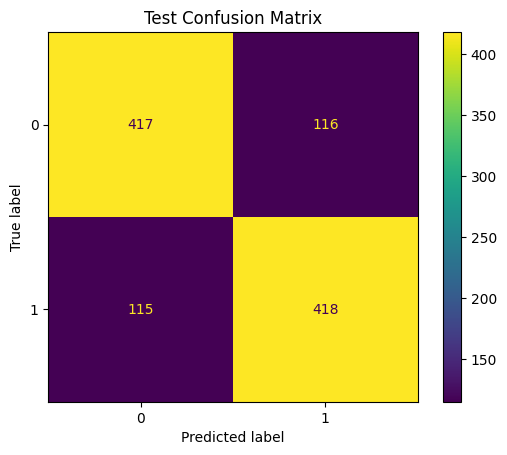

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_test_pred, labels=lr.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=lr.classes_)
disp.plot()
plt.title("Test Confusion Matrix")
plt.show()

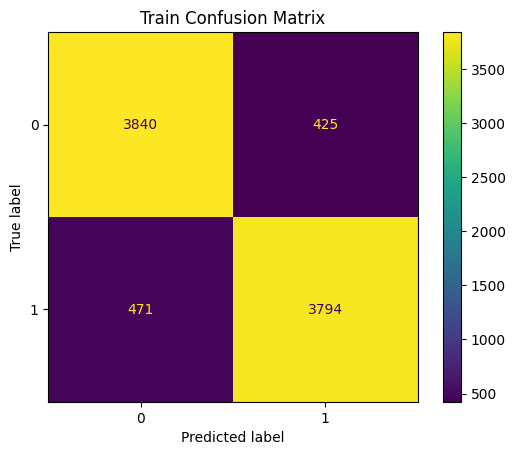

In [24]:
cm = confusion_matrix(y_train, y_train_pred, labels=lr.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=lr.classes_)
disp.plot()
plt.title("Train Confusion Matrix")
plt.show()

In [26]:
# export model weights

joblib.dump(lr, '../artifacts/movie_review_sentiment_lr.joblib')

['../artifacts/movie_review_sentiment_lr.joblib']